<h1><b>Análise Exploratória de Dados</b><br>
<i>Diabetes Health Indicators</i></h1>

<b>O conjunto de dados contém as seguintes variáveis:</b><br><i>
<b>age:</b> Idade do paciente em anos (18–90).<br>
<b>gender:</b> Sexo do paciente. Valores possíveis: 'Masculino', 'Feminino', 'Outro'.<br>
<b>ethnicity:</b> Origem étnica do paciente. Valores possíveis: 'Branco', 'Hispânico', 'Negro', 'Asiático', 'Outro'.<br>
<b>education_level:</b> Nível educacional mais alto concluído. Valores possíveis: 'Sem-Formação', 'Ensino-Médio', 'Graduado', 'Pós-Graduação'.<br>
<b>income_level:</b> Categoria de renda do paciente. Valores possíveis: 'Baixa', 'Médio', 'Alto'.<br>
<b>employment_status:</b> Situação profissional atual. Valores possíveis: 'Empregado', 'Desempregado', 'Aposentado', 'Estudante'.<br>
<b>smoking_status:</b> Histórico de tabagismo. Valores possíveis: 'Nunca', 'Ex-', 'Atual'.<br>
<b>alcohol_consumption_per_week:</b> Quantidade média de bebidas alcoólicas consumidas por semana (0–30).<br>
<b>physical_activity_minutes_per_week:</b> Tempo médio semanal de atividade física em minutos (0–600).<br>
<b>diet_score:</b> Pontuação da qualidade da dieta (0–10), onde valores maiores indicam alimentação mais saudável.<br>
<b>sleep_hours_per_day:</b> Média de horas de sono por dia (3–12).<br>
<b>screen_time_hours_per_day:</b> Média de horas diárias de tempo de tela (0–12).<br>
<b>family_history_diabetes:</b> Indica presença de histórico familiar de diabetes (0 = Não, 1 = Sim).<br>
<b>hypertension_history:</b> Indica histórico de hipertensão (0 = Não, 1 = Sim).<br>
<b>cardiovascular_history:</b> Indica histórico de doenças cardiovasculares (0 = Não, 1 = Sim).<br>
<b>bmi:</b> Índice de Massa Corporal (kg/m²), variando entre 15–45.<br>
<b>waist_to_hip_ratio:</b> Relação entre circunferência da cintura e do quadril (0.7–1.2).<br>
<b>systolic_bp:</b> Pressão arterial sistólica em mmHg (90–180).<br>
<b>diastolic_bp:</b> Pressão arterial diastólica em mmHg (60–120).<br>
<b>heart_rate:</b> Frequência cardíaca em repouso (batimentos por minuto), variando entre 50–120 bpm.<br>
<b>cholesterol_total:</b> Colesterol total no sangue (mg/dL), variando entre 120–300.<br>
<b>hdl_cholesterol:</b> Colesterol HDL (mg/dL), conhecido como “colesterol bom” (20–100).<br>
<b>ldl_cholesterol:</b> Colesterol LDL (mg/dL), conhecido como “colesterol ruim” (50–200).<br>
<b>triglycerides:</b> Nível de triglicerídeos no sangue (mg/dL), variando entre 50–500.<br>
<b>glucose_fasting:</b> Glicemia em jejum (mg/dL), variando entre 70–250.<br>
<b>glucose_postprandial:</b> Glicemia após refeição (mg/dL), variando entre 90–350.<br>
<b>insulin_level:</b> Nível de insulina no sangue (μU/mL), variando entre 2–50.<br>
<b>hba1c:</b> Hemoglobina glicada (%), indicador da média de glicose nos últimos meses (4–14%).<br>
<b>diabetes_risk_score:</b> Pontuação calculada de risco de diabetes (0–100), onde valores maiores indicam maior risco estimado.<br>
<b>diabetes_stage:</b> Estágio da condição relacionada ao diabetes. Valores possíveis: 'Sem Diabetes', 'Pré-Diabetes', 'Tipo 1', 'Tipo 2', 'Gestacional'.<br>
<b>diagnosed_diabetes:</b> Variável alvo. Indica se o paciente foi diagnosticado com diabetes (0 = Não, 1 = Sim).<br>

### Importação das Bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from scipy.stats import chi2_contingency

Configurações de estilo para os gráficos

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'utils')))

from plot_config import set_seaborn
set_seaborn()

### Importação e pré-visualização dos dados

In [3]:
df_raw = pd.read_csv("./../../data/raw/diabetes_health_indicators.csv")
pd.options.display.float_format = '{:.2f}'.format

display(df_raw.head().T)
registros = df_raw.shape[0]
print(f"\n{registros} registros e {df_raw.shape[1]} variáveis")

,0,1,2,3,4
age,58,48,60,74,46
gender,Male,Female,Male,Female,Male
ethnicity,Asian,White,Hispanic,Black,White
education_level,Highschool,Highschool,Highschool,Highschool,Graduate
income_level,Lower-Middle,Middle,Middle,Low,Middle
employment_status,Employed,Employed,Unemployed,Retired,Retired
smoking_status,Never,Former,Never,Never,Never
alcohol_consumption_per_week,0,1,1,0,1
physical_activity_minutes_per_week,215,143,57,49,109
diet_score,5.70,6.70,6.40,3.40,7.20



100000 registros e 31 variáveis


In [4]:
df_columns = [
    "age",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi"
]

df = df_raw[df_columns]

### Quantidade de dados nulos

In [5]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
dtype: int64

### Tipos de dados

In [6]:
df.dtypes

age                                     int64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
dtype: object

### Análise das variáveis categóricas
Categorias em cada variável

In [7]:
for i in df.select_dtypes(include="str").columns:
  print(f"{i}: {df[i].unique()}\n")

gender: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

ethnicity: <StringArray>
['Asian', 'White', 'Hispanic', 'Black', 'Other']
Length: 5, dtype: str

education_level: <StringArray>
['Highschool', 'Graduate', 'Postgraduate', 'No formal']
Length: 4, dtype: str

income_level: <StringArray>
['Lower-Middle', 'Middle', 'Low', 'Upper-Middle', 'High']
Length: 5, dtype: str

employment_status: <StringArray>
['Employed', 'Unemployed', 'Retired', 'Student']
Length: 4, dtype: str

smoking_status: <StringArray>
['Never', 'Former', 'Current']
Length: 3, dtype: str



Quantidade de dados de cada categoria

In [8]:
for i in df.select_dtypes(include="str").columns:
    print(f"{df[i].value_counts()}\n")

gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64



Proporção entre categoria e o alvo

In [9]:
for i in df.select_dtypes(include="str").columns:
    print(f"{df_raw.groupby(i)['diagnosed_diabetes'].mean()}\n")

gender
Female   0.60
Male     0.60
Other    0.62
Name: diagnosed_diabetes, dtype: float64

ethnicity
Asian      0.60
Black      0.60
Hispanic   0.59
Other      0.61
White      0.60
Name: diagnosed_diabetes, dtype: float64

education_level
Graduate       0.60
Highschool     0.60
No formal      0.60
Postgraduate   0.59
Name: diagnosed_diabetes, dtype: float64

income_level
High           0.61
Low            0.60
Lower-Middle   0.60
Middle         0.60
Upper-Middle   0.60
Name: diagnosed_diabetes, dtype: float64

employment_status
Employed     0.60
Retired      0.60
Student      0.60
Unemployed   0.60
Name: diagnosed_diabetes, dtype: float64

smoking_status
Current   0.60
Former    0.60
Never     0.60
Name: diagnosed_diabetes, dtype: float64



### Teste Qui-quadrado.

Um valor de p <= 0.05 rejeitamos a hipótese nula,<br>
ou seja, há uma relação significativa.

In [10]:
print("Teste para todas as variáveis do dataset:\n")
for col in df_raw.columns:
    tabela = pd.crosstab(df_raw[col], df_raw["diagnosed_diabetes"])
    chi2, p, _, _ = chi2_contingency(tabela)
    print(f"{col} -> p-value: {p}")

Teste para todas as variáveis do dataset:

age -> p-value: 0.0
gender -> p-value: 0.09880536552392973
ethnicity -> p-value: 0.32118294592539454
education_level -> p-value: 0.3400828191688993
income_level -> p-value: 0.3554183584482451
employment_status -> p-value: 0.38922869181679415
smoking_status -> p-value: 0.927242187198018
alcohol_consumption_per_week -> p-value: 0.5812353707620096
physical_activity_minutes_per_week -> p-value: 6.911920604699961e-100
diet_score -> p-value: 2.3085120669805283e-23
sleep_hours_per_day -> p-value: 0.762969942207953
screen_time_hours_per_day -> p-value: 0.02608958595596778
family_history_diabetes -> p-value: 0.0
hypertension_history -> p-value: 3.4241983471994062e-18
cardiovascular_history -> p-value: 4.986577016347968e-21
bmi -> p-value: 6.769041219391212e-120
waist_to_hip_ratio -> p-value: 8.714568473662497e-113
systolic_bp -> p-value: 4.1820247152489256e-156
diastolic_bp -> p-value: 3.315673157854912e-15
heart_rate -> p-value: 1.6289029002711618e-06

Alvo

In [11]:
pd.crosstab(pd.qcut(df_raw["hba1c"], 4),
            df_raw["diagnosed_diabetes"],
            normalize="index")

diagnosed_diabetes,0,1
hba1c,,
"(3.999, 5.97]",0.84,0.16
"(5.97, 6.52]",0.75,0.25
"(6.52, 7.07]",0.00,1.00
"(7.07, 9.8]",0.00,1.00


### Análise de Outilies

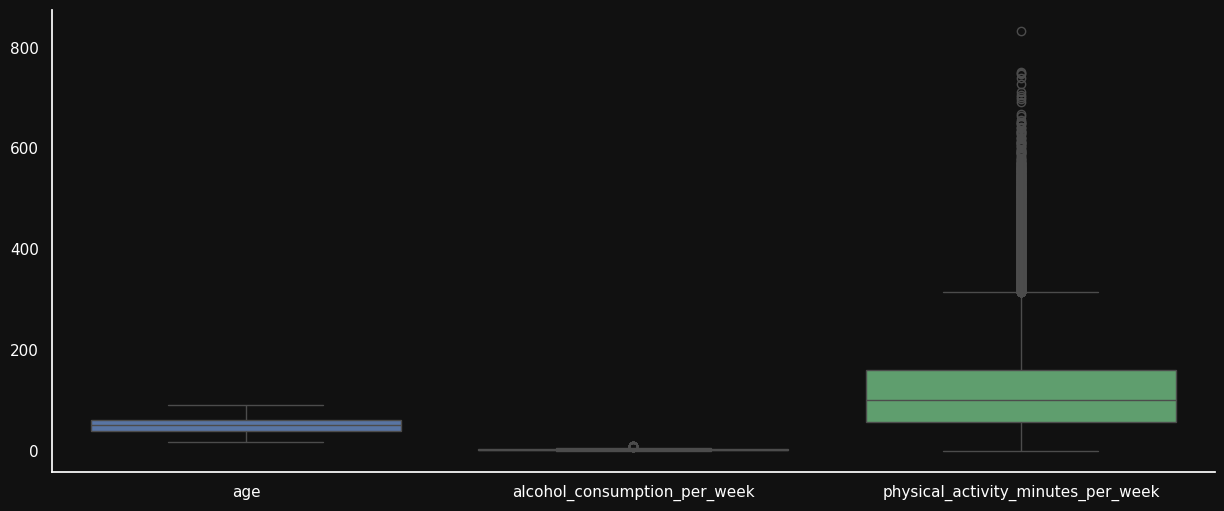

In [12]:
numericas_int = df.select_dtypes(include="int").columns

sns.boxplot(df[numericas_int]);

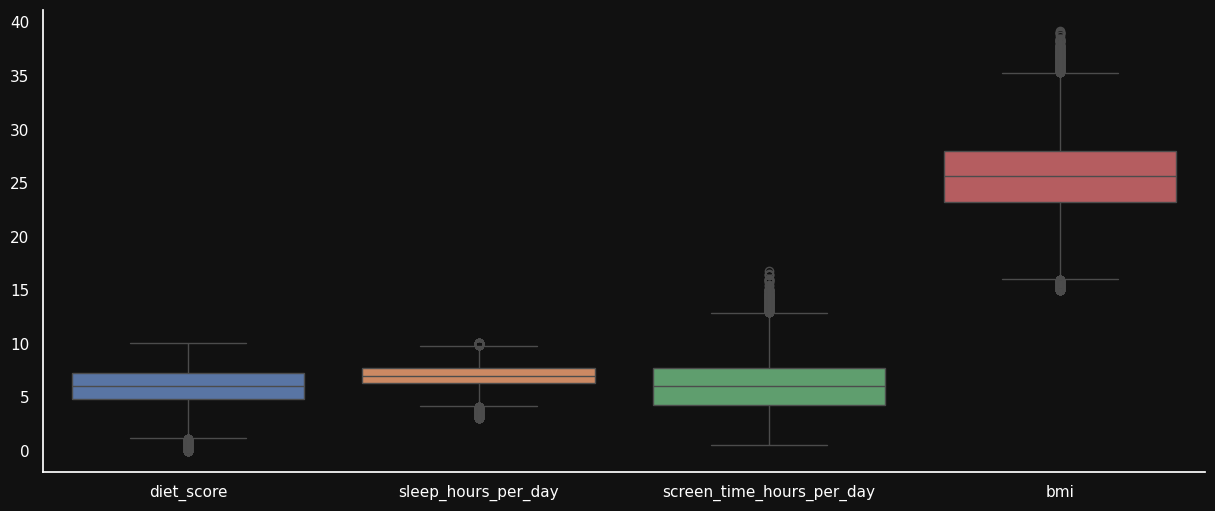

In [13]:
numericas_float = df.select_dtypes(include="float").columns

sns.boxplot(df[numericas_float]);

Regra do 1,5 × Distância Interquartílica para identificação de Outlires

In [22]:
numericas = df.select_dtypes(include="number").columns

for i in df[numericas].columns:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  outliers_iqr = df[(df[i] < limite_inferior) | (df[i] > limite_superior)]

  print(f"Mínimo da variável '{i}' = {df[i].min()}\nMáximo da variável '{i}' = {df[i].max()}")
  print(f"Limites da variável '{i}' = {round(limite_inferior, 2)} a {round(limite_superior, 2)}")
  print(f"Menor outlier: {outliers_iqr[i].min()}, Maior outlier: {outliers_iqr[i].max()}\n")

Mínimo da variável 'age' = 18
Máximo da variável 'age' = 90
Limites da variável 'age' = 6.0 a 94.0
Menor outlier: nan, Maior outlier: nan

Mínimo da variável 'alcohol_consumption_per_week' = 0
Máximo da variável 'alcohol_consumption_per_week' = 10
Limites da variável 'alcohol_consumption_per_week' = -2.0 a 6.0
Menor outlier: 7, Maior outlier: 10

Mínimo da variável 'physical_activity_minutes_per_week' = 0
Máximo da variável 'physical_activity_minutes_per_week' = 833
Limites da variável 'physical_activity_minutes_per_week' = -97.5 a 314.5
Menor outlier: 315, Maior outlier: 833

Mínimo da variável 'diet_score' = 0.0
Máximo da variável 'diet_score' = 10.0
Limites da variável 'diet_score' = 1.2 a 10.8
Menor outlier: 0.0, Maior outlier: 1.1

Mínimo da variável 'sleep_hours_per_day' = 3.0
Máximo da variável 'sleep_hours_per_day' = 10.0
Limites da variável 'sleep_hours_per_day' = 4.2 a 9.8
Menor outlier: 3.0, Maior outlier: 10.0

Mínimo da variável 'screen_time_hours_per_day' = 0.5
Máximo da 

### Proporção de dados na variável alvo

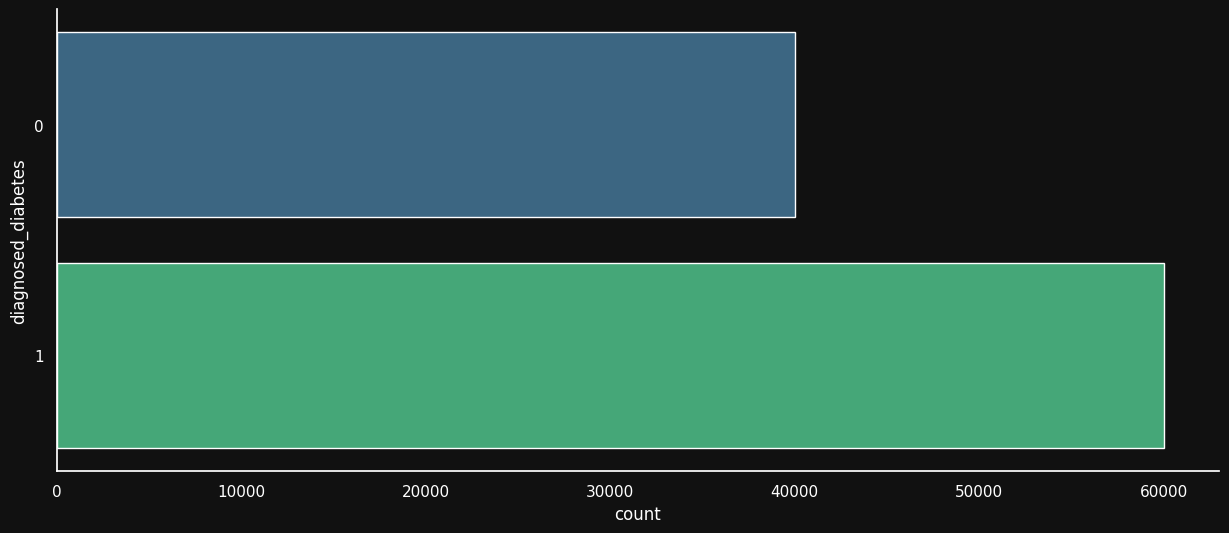

In [18]:
sns.countplot(y=df_raw["diagnosed_diabetes"], palette="viridis", hue=df_raw["diagnosed_diabetes"], legend=False);

In [20]:
proportion_diabetes = df_raw["diagnosed_diabetes"].value_counts(normalize=True)
count_diabetes = df_raw["diagnosed_diabetes"].value_counts()

print(f"Quantidade de dados com pacientes negativo para diabetes: {count_diabetes[0]}")
print(f"Quantidade de dados com pacientes positivo para diabetes: {count_diabetes[1]}\n")

print(f"Proporção de negativos para diabetes: {float(proportion_diabetes[0])}")
print(f"Proporção de positivos para diabetes: {float(proportion_diabetes[1])}\n")

if float(proportion_diabetes[0]) < 0.35 or float(proportion_diabetes[1]) < 0.35:
    print("Dados desbalanceados.")
else:
    print("Perfeito!\nDados balanceados.")

Quantidade de dados com pacientes negativo para diabetes: 40002
Quantidade de dados com pacientes positivo para diabetes: 59998

Proporção de negativos para diabetes: 0.40002
Proporção de positivos para diabetes: 0.59998

Perfeito!
Dados balanceados.
